# Input Maps, Target Climatology & Obs vs Pred

1. **Auxiliary static inputs** — all `vars_aux` channels
2. **Level input snapshot** — ta, hus, ua, va at 700 hPa (first sample)
3. **Target climatology** — time-mean total cloud cover
4. **Observed vs Predicted** — mean maps, bias, and scatter

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [ ]:
VAL_ZARR_PATH = "../data/train_data/val_era5_region1.zarr"
FORECAST_DIR = "../data/forecasts"
FORECAST_FILE = "val_era5_region1.nc"

EXPERIMENTS = [
    ("unet_brute_xlarge", "UNet XLarge"),
    ("geounet_wide_rh_hilr", "GeoUNet Wide RH"),
    ("segformer_b2_rh", "SegFormer B2 RH"),
    ("baseline_mlp", "MLP Baseline"),
]

In [ ]:
ds_val = xr.open_zarr(VAL_ZARR_PATH)

# Normalize longitudes from [0, 360) to [-180, 180) for Cartopy
lon_norm = ((ds_val.lon.values + 180) % 360) - 180
ds_val = ds_val.assign_coords(lon=lon_norm).sortby("lon")

lat = ds_val.lat.values
lon = ds_val.lon.values
sample_dim = "time" if "time" in ds_val.input_level.dims else "sample"
print(f"Using sample dimension: {sample_dim}")
ds_val

Using sample dimension: sample


<xarray.Dataset> Size: 174MB
Dimensions:          (vars_aux: 8, lat: 64, lon: 64, sample: 365,
                      vars_level: 4, level: 7)
Coordinates:
  * vars_aux         (vars_aux) <U23 736B 'land_sea_mask' ... 'type_of_high_v...
  * lat              (lat) float64 512B -30.0 -28.5 -27.0 ... 61.5 63.0 64.5
  * lon              (lon) float64 512B -60.0 -58.5 -57.0 ... 31.5 33.0 34.5
  * vars_level       (vars_level) <U3 48B 'ta' 'hus' 'ua' 'va'
  * level            (level) int64 56B 1000 850 700 500 250 100 50
Dimensions without coordinates: sample
Data variables:
    input_auxiliary  (vars_aux, lat, lon) float32 131kB dask.array<chunksize=(8, 64, 64), meta=np.ndarray>
    input_level      (sample, vars_level, level, lat, lon) float32 167MB dask.array<chunksize=(1, 4, 7, 64, 64), meta=np.ndarray>
    target           (sample, lat, lon) float32 6MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>

In [ ]:
PROJ = ccrs.PlateCarree()


def map_ax(ax, data, lat, lon, cmap, vmin=None, vmax=None, cbar_label=""):
    """Filled pcolormesh map with coastlines on a Cartopy axes."""
    im = ax.pcolormesh(
        lon, lat, data, transform=PROJ, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto"
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=PROJ)
    plt.colorbar(
        im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.9, label=cbar_label
    )
    return im

## 1. Auxiliary static inputs

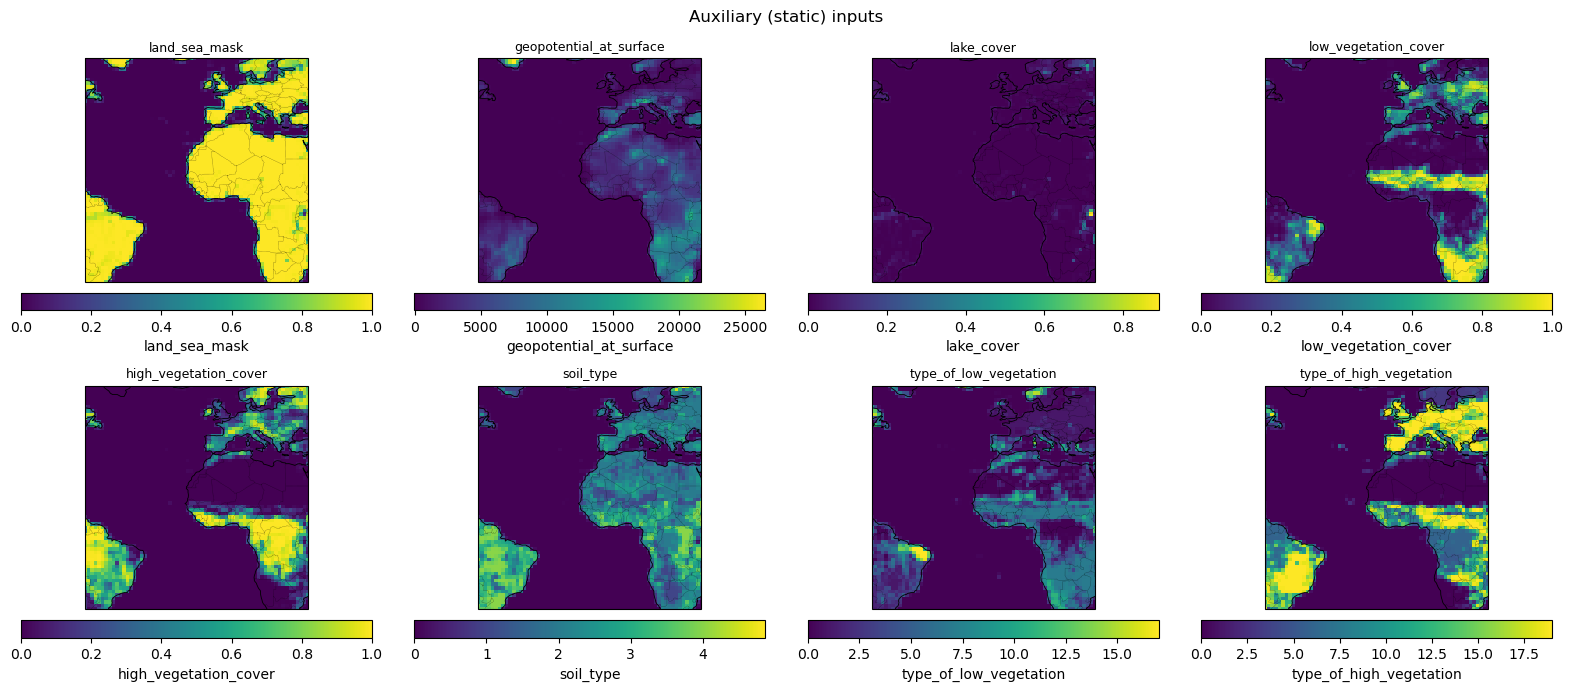

In [ ]:
aux = ds_val.input_auxiliary.compute()
vars_aux = aux.vars_aux.values

ncols = 4
nrows = int(np.ceil(len(vars_aux) / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), subplot_kw={"projection": PROJ}
)
axes = np.array(axes).flatten()

for i, var in enumerate(vars_aux):
    data = aux.sel(vars_aux=var).values
    map_ax(axes[i], data, lat, lon, cmap="viridis", cbar_label=var)
    axes[i].set_title(var, fontsize=9)

for ax in axes[len(vars_aux) :]:
    ax.set_visible(False)

fig.suptitle("Auxiliary (static) inputs", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Level input snapshot (700 hPa, first sample)

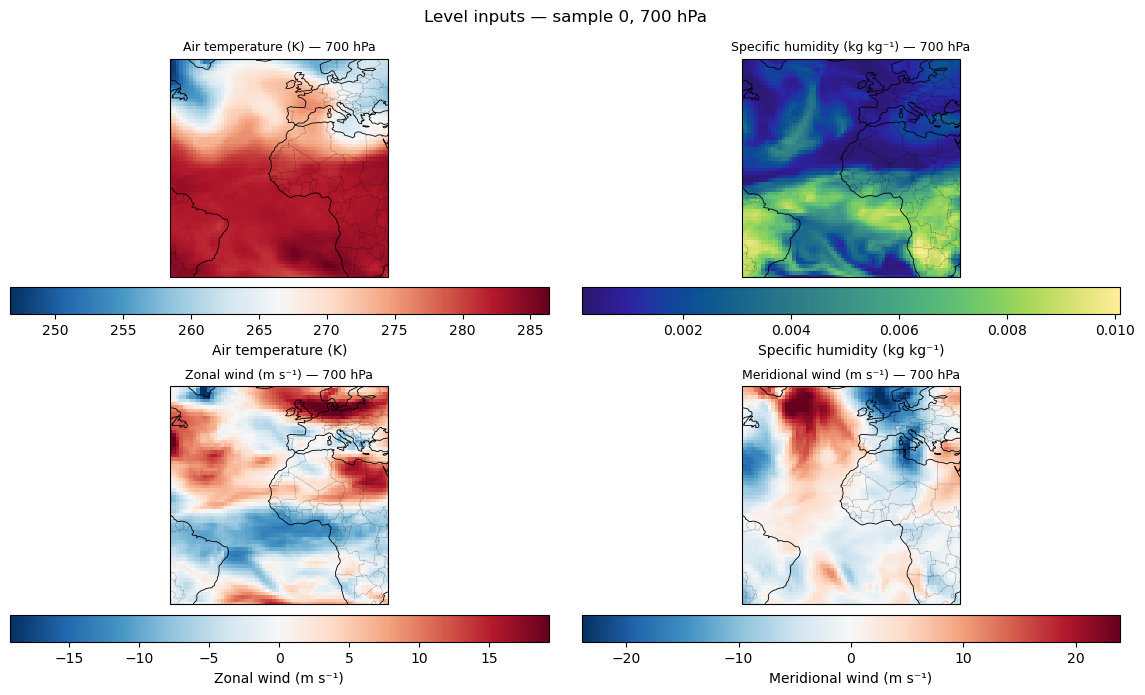

In [ ]:
LEVEL = 700
SAMPLE_IDX = 0

LONG_NAMES = {
    "ta": "Air temperature (K)",
    "hus": "Specific humidity (kg kg⁻¹)",
    "ua": "Zonal wind (m s⁻¹)",
    "va": "Meridional wind (m s⁻¹)",
}
CMAPS = {"ta": "RdBu_r", "hus": cmocean.cm.haline, "ua": "RdBu_r", "va": "RdBu_r"}

snap = ds_val.input_level.isel({sample_dim: SAMPLE_IDX}).sel(level=LEVEL).compute()

fig, axes = plt.subplots(2, 2, figsize=(12, 7), subplot_kw={"projection": PROJ})
axes = axes.flatten()

for i, var in enumerate(LONG_NAMES):
    data = snap.sel(vars_level=var).values
    vabs = float(np.nanpercentile(np.abs(data), 99))
    if var in ("ua", "va"):
        map_ax(
            axes[i],
            data,
            lat,
            lon,
            cmap=CMAPS[var],
            vmin=-vabs,
            vmax=vabs,
            cbar_label=LONG_NAMES[var],
        )
    else:
        map_ax(axes[i], data, lat, lon, cmap=CMAPS[var], cbar_label=LONG_NAMES[var])
    axes[i].set_title(f"{LONG_NAMES[var]} — {LEVEL} hPa", fontsize=9)

fig.suptitle(f"Level inputs — sample {SAMPLE_IDX}, {LEVEL} hPa", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Target climatology (time-mean cloud cover)

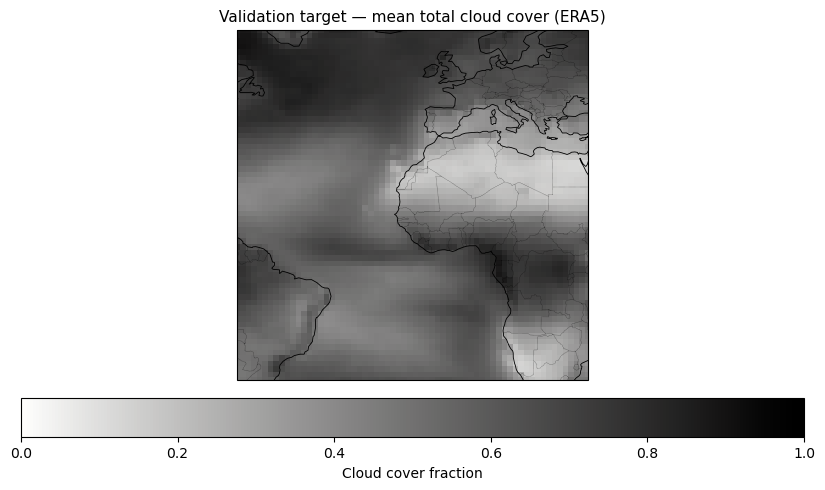

In [ ]:
target_clim = ds_val.target.mean(sample_dim).compute()

fig, ax = plt.subplots(1, 1, figsize=(9, 5), subplot_kw={"projection": PROJ})
map_ax(
    ax,
    target_clim.values,
    lat,
    lon,
    cmap=cmocean.cm.gray_r,
    vmin=0,
    vmax=1,
    cbar_label="Cloud cover fraction",
)
ax.set_title("Validation target — mean total cloud cover (ERA5)", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Observed vs Predicted — multi-model comparison

In [ ]:
import os

obs = ds_val.target.compute()  # (time, lat, lon)

results = {}
for exp_key, label in EXPERIMENTS:
    path = os.path.join(FORECAST_DIR, exp_key, FORECAST_FILE)
    if not os.path.exists(path):
        print(f"[skip] {exp_key}: {path} not found")
        continue
    ds_pred = xr.open_dataset(path)
    lon_pred_norm = ((ds_pred.lon.values + 180) % 360) - 180
    ds_pred = ds_pred.assign_coords(lon=lon_pred_norm).sortby("lon")
    pred = ds_pred.total_cloud_cover.compute()
    assert obs.shape == pred.shape, (
        f"{exp_key}: shape mismatch obs {obs.shape} vs pred {pred.shape}"
    )
    mae = float(np.abs(obs.values - pred.values).mean())
    results[exp_key] = {"label": label, "pred": pred, "mae": mae}
    print(f"{label:30s}  MAE = {mae:.4f}")

print(f"\nLoaded {len(results)}/{len(EXPERIMENTS)} experiments")

UNet XLarge                     MAE = 0.0763
GeoUNet Wide RH                 MAE = 0.0750
SegFormer B2 RH                 MAE = 0.1055
MLP Baseline                    MAE = 0.0926

Loaded 4/4 experiments


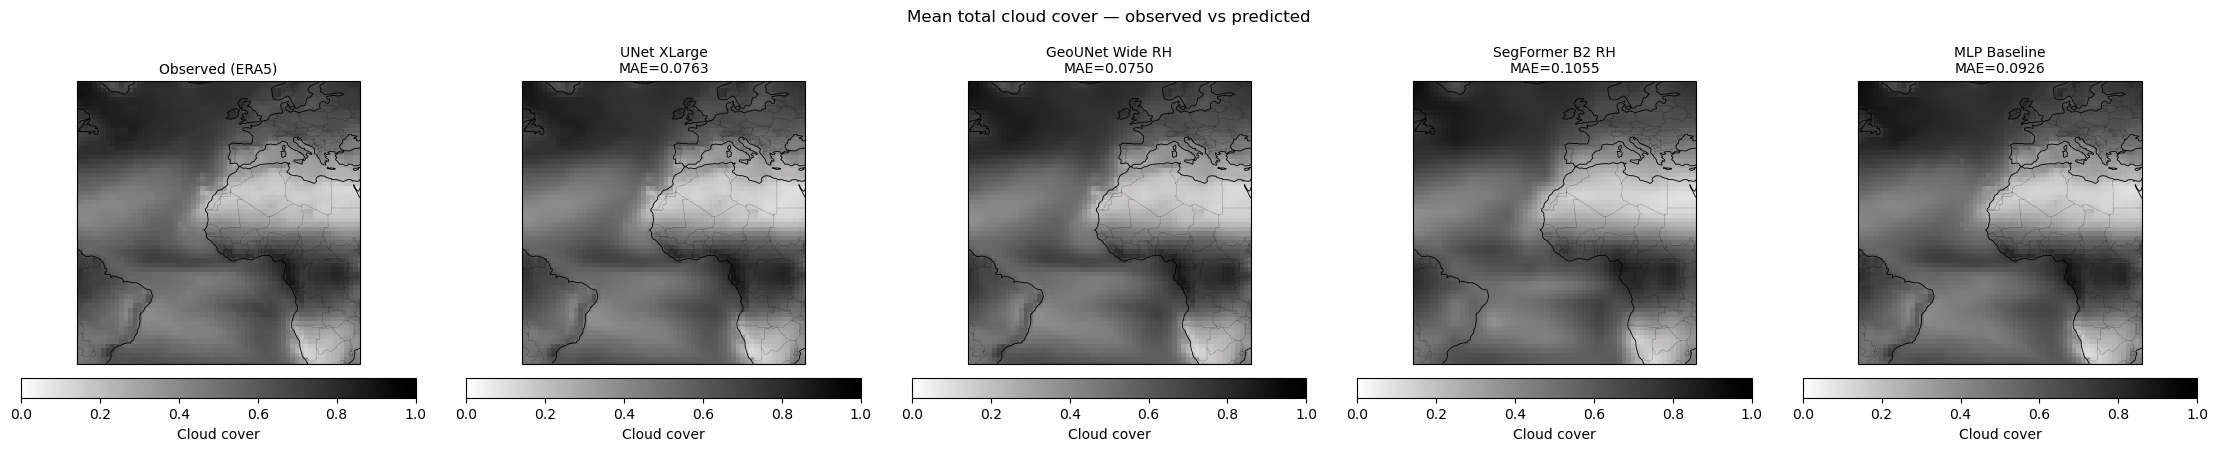

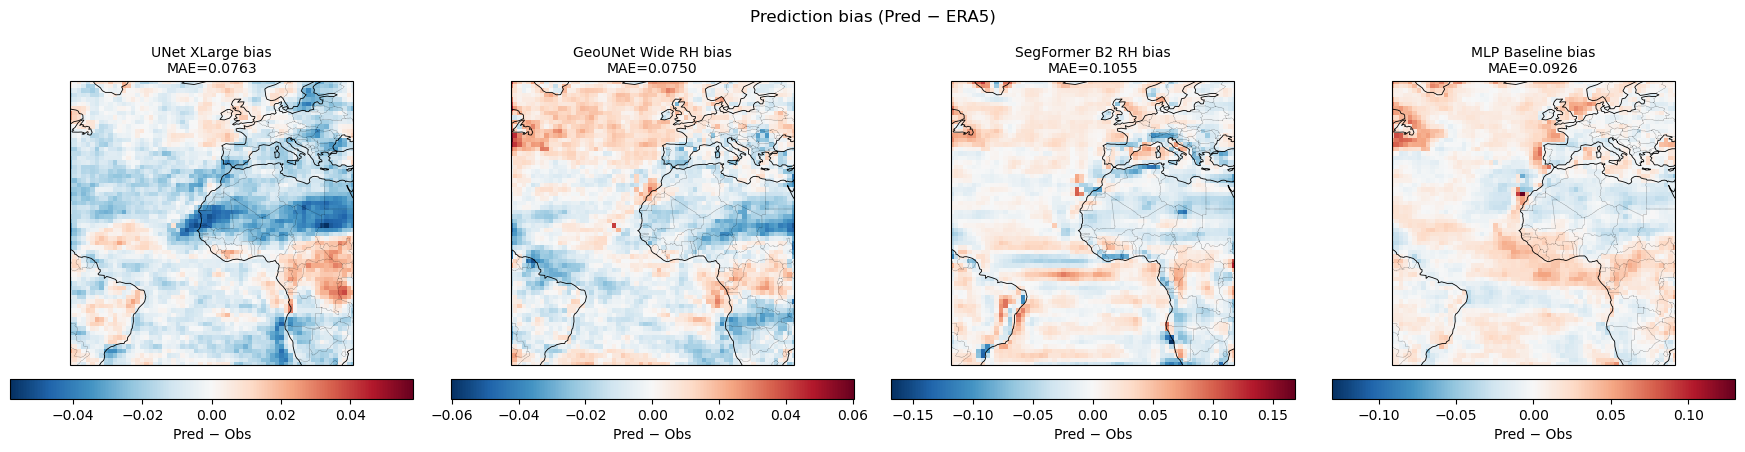

In [ ]:
obs_mean = obs.mean(sample_dim).values
n = len(results)

# --- Mean cloud cover maps: obs + all predicted means ---
ncols = n + 1
fig, axes = plt.subplots(
    1, ncols, figsize=(4.5 * ncols, 4.5), subplot_kw={"projection": PROJ}
)

map_ax(
    axes[0],
    obs_mean,
    lat,
    lon,
    cmap=cmocean.cm.gray_r,
    vmin=0,
    vmax=1,
    cbar_label="Cloud cover",
)
axes[0].set_title("Observed (ERA5)", fontsize=10)

for ax, (exp_key, r) in zip(axes[1:], results.items()):
    pred_mean = r["pred"].mean("sample").values
    map_ax(
        ax,
        pred_mean,
        lat,
        lon,
        cmap=cmocean.cm.gray_r,
        vmin=0,
        vmax=1,
        cbar_label="Cloud cover",
    )
    ax.set_title(f"{r['label']}\nMAE={r['mae']:.4f}", fontsize=10)

fig.suptitle("Mean total cloud cover — observed vs predicted", fontsize=12)
plt.tight_layout()
plt.show()

# --- Bias maps ---
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5), subplot_kw={"projection": PROJ})
if n == 1:
    axes = [axes]

for ax, (exp_key, r) in zip(axes, results.items()):
    bias = r["pred"].mean("sample").values - obs_mean
    vmax_b = float(np.abs(bias).max())
    map_ax(
        ax,
        bias,
        lat,
        lon,
        cmap="RdBu_r",
        vmin=-vmax_b,
        vmax=vmax_b,
        cbar_label="Pred − Obs",
    )
    ax.set_title(f"{r['label']} bias\nMAE={r['mae']:.4f}", fontsize=10)

fig.suptitle("Prediction bias (Pred − ERA5)", fontsize=12)
plt.tight_layout()
plt.show()

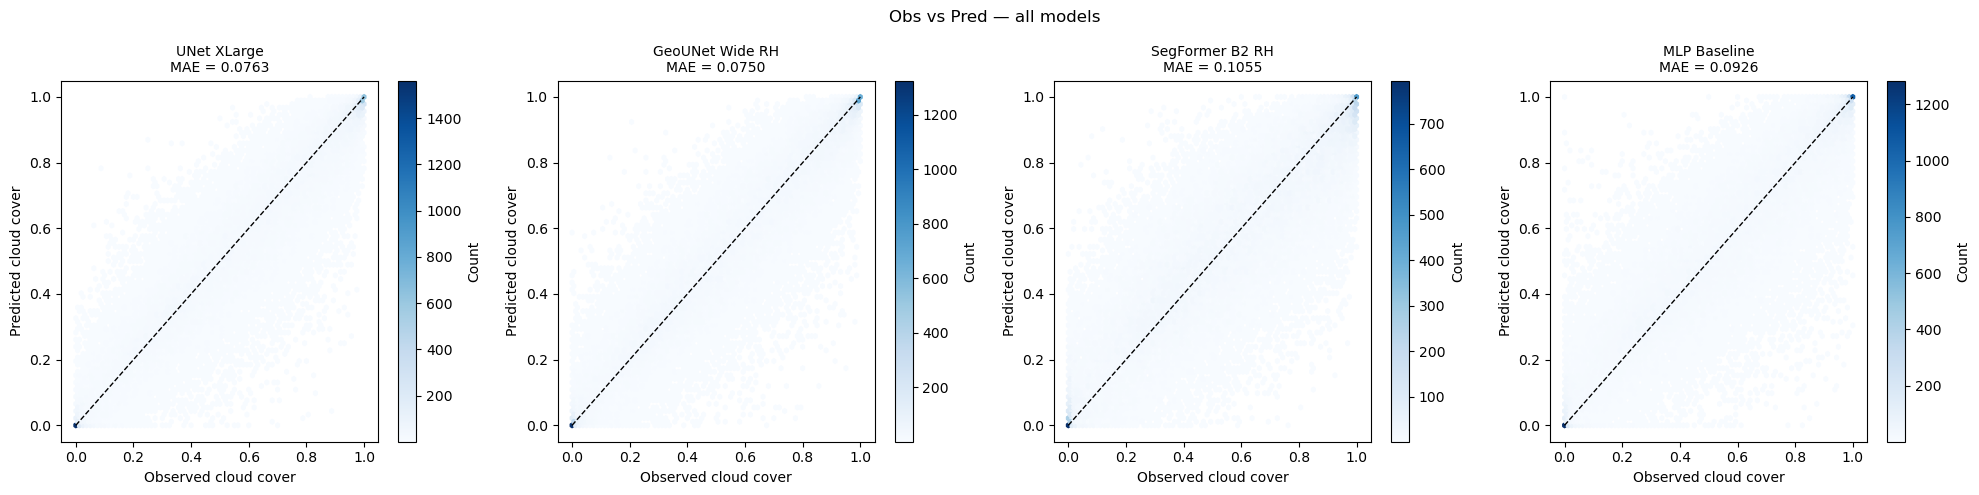

In [ ]:
rng = np.random.default_rng(42)
n_scatter = min(50_000, obs.values.size)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for ax, (exp_key, r) in zip(axes, results.items()):
    obs_flat = obs.values.ravel()
    pred_flat = r["pred"].values.ravel()
    idx = rng.choice(len(obs_flat), size=n_scatter, replace=False)
    hb = ax.hexbin(
        obs_flat[idx],
        pred_flat[idx],
        gridsize=80,
        cmap="Blues",
        extent=[0, 1, 0, 1],
        mincnt=1,
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.colorbar(hb, ax=ax, label="Count")
    ax.set_xlabel("Observed cloud cover")
    ax.set_ylabel("Predicted cloud cover")
    ax.set_title(f"{r['label']}\nMAE = {r['mae']:.4f}", fontsize=10)

fig.suptitle("Obs vs Pred — all models", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Blog post figure — observed mean + predicted means + bias maps

In [ ]:
nrows = n + 1  # obs row + one per model
fig, axes = plt.subplots(
    nrows,
    2,
    figsize=(9, 4.0 * nrows),
    subplot_kw={"projection": PROJ},
)

# Row 0: observed mean (col 0), blank (col 1)
map_ax(
    axes[0, 0],
    obs_mean,
    lat,
    lon,
    cmap=cmocean.cm.gray_r,
    vmin=0,
    vmax=1,
    cbar_label="Cloud cover",
)
axes[0, 0].set_title("Observed (ERA5)", fontsize=11, fontweight="bold")
axes[0, 1].set_visible(False)

# Rows 1..N: predicted mean (col 0), bias (col 1)
for row, (exp_key, r) in enumerate(results.items(), start=1):
    pred_mean = r["pred"].mean("sample").values
    bias = pred_mean - obs_mean
    vmax_b = float(np.abs(bias).max())

    map_ax(
        axes[row, 0],
        pred_mean,
        lat,
        lon,
        cmap=cmocean.cm.gray_r,
        vmin=0,
        vmax=1,
        cbar_label="Cloud cover",
    )
    axes[row, 0].set_title(f"{r['label']}", fontsize=11, fontweight="bold")

    map_ax(
        axes[row, 1],
        bias,
        lat,
        lon,
        cmap="RdBu_r",
        vmin=-vmax_b,
        vmax=vmax_b,
        cbar_label="Pred − Obs",
    )
    axes[row, 1].set_title(f"{r['label']} bias  |  MAE={r['mae']:.4f}", fontsize=9)

fig.suptitle("Total cloud cover — model comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("blog_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: blog_model_comparison.png")